In [ ]:
import numpy as np
import pandas as pd
from math import *
#scipy stat
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
import math
import os
import matplotlib.pyplot as plt
import seaborn as sns


###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler                    

# tree
# linear_model
from sklearn.linear_model import LogisticRegression


In [ ]:
def tableDispFormatt(yourString):
    fixLen = 90
    startLine = '==============================='
    textLen = len(yourString)
    endLineLen = fixLen - (len(startLine)+textLen)
    endLine = ''
    for i in np.arange(0,endLineLen,1):
        endLine += '='
    print(startLine,yourString,endLine)

In [ ]:
path = os.path.join(os.getcwd(), 'smart_grid_stability_augmented_dataset','smart_grid_stability_augmented.csv')
df = pd.read_csv(path)
print(df.columns.values)
print(f'Columns name:\n {df.columns}')
print(f'Categorical variable count: {df['stabf'].value_counts()}')
# Info summary
df.info()
# descriptive statistics for numeric columns
df.describe()

# Analysis nominal power consumed and see effect on stability

p1 = abs(p2 + p3 + p4)

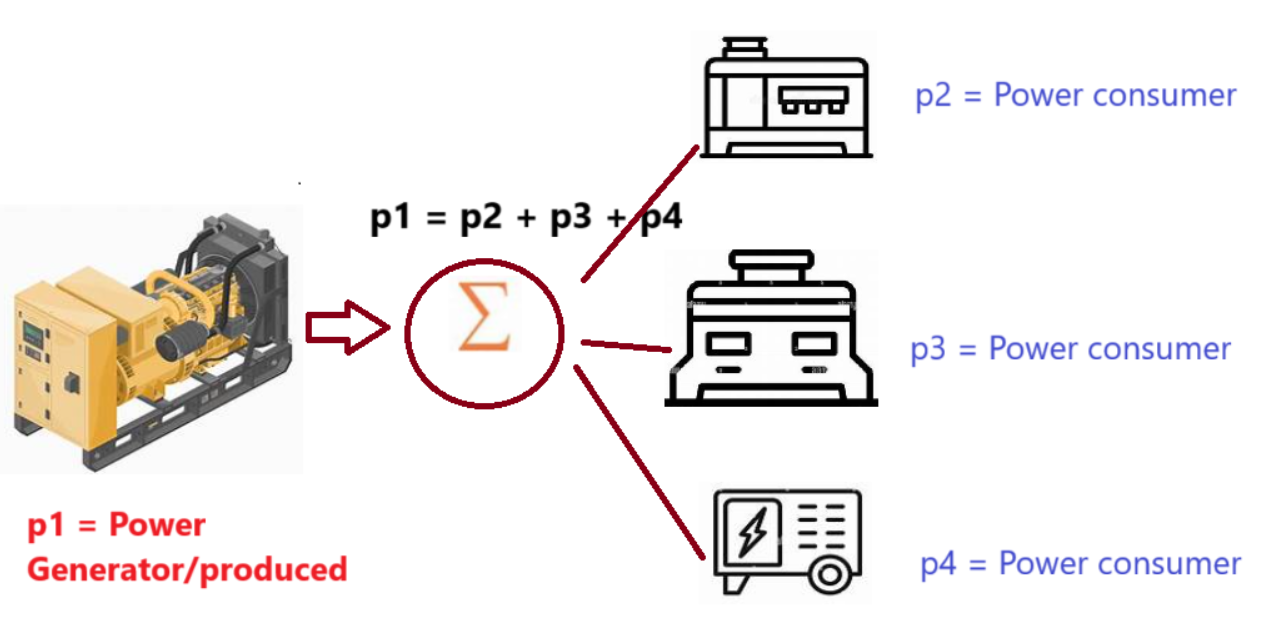

In [ ]:
# Variables to plot
variables = ["p1","p2","p3","p4"]
df['pAdd'] = abs(df['p2'] + df['p3'] + df['p4'])
print(f'is p1 == abs(p2+p3+p4) ==> {df['pAdd'].sum() == df['p1'].sum()}')
fig, axes = plt.subplots(4, 1, figsize=(6, 15))
# Variables to plot
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    sns.barplot(data=df, x='stabf', y = var,hue="stabf",errorbar='sd', legend=False,ax=axes[i])
    axes[i].set_title(f"Strip of {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Standard Error")
plt.tight_layout()

Barplot figure displays four separate bar charts (Stripped of p1 to p4) that likely illustrate the results of a simulation or experiment related to electrical grid stability.

- p1 = Nominal power produced (positive, real).
- p2, p3, p4 = Nominal power consumed (negative).
- The balance condition is defined as 
  - $P1 + P2 + P3 + P4 =0$

**Stable State (Orange)**: The standard error bars are very short, indicating that when the system is stable, the power outputs/consumptions are consistent and close to their nominal (expected) values.

**Unstable State (Blue)**: The standard error bars are much longer, particularly for p1, indicating a large degree of variability and deviation in the power output under unstable conditions. This aligns with the concept of grid instability, where power balance is difficult to maintain and can **result in large fluctuations or even a system collapse (blackout)**. 

The figures visually demonstrate that maintaining the power balance condition $P1 + P2 + P3 + P4 =0$ is associated with significantly reduced variability (standard error) in the power flows (p1, p2, p3, p4), thereby confirming the system operates more reliably and predictably when stable.

### Check P1 = P2 + P3 + P4

In [ ]:
dfPwr = df.loc[:,['p1', 'p2', 'p3', 'p4','stabf']]
for col in dfPwr.select_dtypes(include=np.number).columns:
    dfPwr[col + "_status"] = dfPwr[col].apply(
        lambda x: "produced" if x > 0 else ("consumed" if x < 0 else "neutral")
    )
print(dfPwr['p1_status'].value_counts())
print(dfPwr['p2_status'].value_counts())
print(dfPwr['p3_status'].value_counts())
print(dfPwr['p4_status'].value_counts())

In [ ]:
sns.lmplot( data=df,x = 'p1',y = 'pAdd',hue = 'stabf',col="stabf", line_kws={"color": "red"})
df.drop(['pAdd'],inplace=True,axis='columns')

- p1 = Power generated by the main generator.
- pAdd = p2+p3+p4, i.e., the sum of additional power sources (auxiliary generators or distributed units).

Linear Relationship:
- Both in stable and unstable conditions, pAdd and p1 show a linear trend.
- This means as p1 increases, pAdd also increases proportionally.
Mathematically, we can express it as:

$pAdd$ = $\alpha$ + $\beta$ $\cdot$ $p1$

- Slope ($\beta$): Indicates how much additional generation (pAdd) rises for each unit increase in p1.
- Intercept ($\alpha$ ): Baseline contribution from auxiliary sources when p1 = 0.

#### Correlation heatmap

In [ ]:
# Compute correlation matrix
corr = dfPwr.corr(numeric_only=True)

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Draw the heatmap with the mask
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f",
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Lower Triangle Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

- Values close to -1.0 (dark blue) indicate a strong negative linear correlation. When one variable increases, the other decreases.
- Values close to 0.0 (red/orange) indicate a weak or no linear correlation.

**p1 and the other consumer nodes (p2, p3, p4):** There are moderate to strong negative correlations (-0.57 and -0.58). This aligns with your description, as production (p1) must generally increase when consumption (p2, p3, p4) increases, meaning they move in opposite directions to maintain the power balance in the grid.

**p2 and p3:** The correlation is 0.00, indicating almost **no linear relationship** between the power consumed at these two specific nodes within this dataset.

**p2 and p4:** The correlation is -0.01, also indicating negligible linear correlation.

**p3 and p4:** The correlation is 0.01, indicating a very weak positive linear correlation.

#### "Hist Plot of p1 with Skew and Kurtosis

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(6, 15))
# Variables to plot
variables = ["p1", "p2", "p3",'p4']
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    sns.histplot(data=dfPwr, x=var,bins=70, kde=True,ax=axes[i])
    # Calculate skewness and kurtosis
    skew_val = skew(df[var])
    kurt_val = kurtosis(df[var])  # Default is Fisher's definition (excess kurtosis)
    variance = dfPwr[var].var()
    axes[i].set_title(f"Hist Plot of {var} with Skew and Kurtosis")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel(var + ' Frequency')
    axes[i].text(x=df[var].mean(), y=10,
         s=f"Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f},Variance: {variance:.2f}",
         fontsize=12,color='red', bbox=dict(facecolor='white', alpha=0.6))
plt.tight_layout()

### Statistical Metrics (Skewness, Kurtosis, Variance)

The statistics displayed in each plot provide a numerical description of the shape of the distributions:

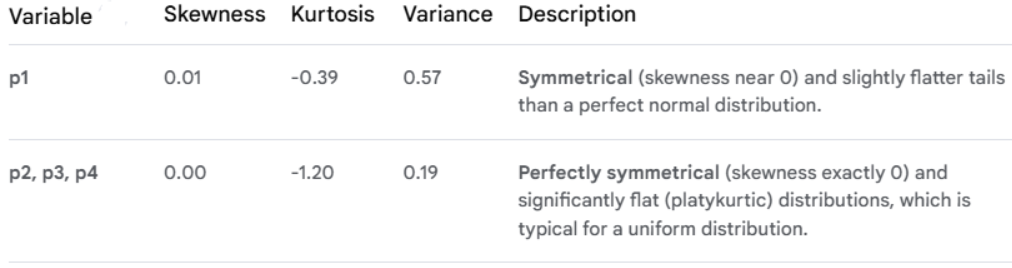

#### The distributions illustrate different data generation strategies:

- The uniform distribution for p2, p3, and p4 suggests that these consumer powers were likely generated using a random process that selected values evenly from a fixed range.

- The normal distribution for p1 is a result of it being the sum of the absolute values of the other three variables, naturally forming a bell curve as expected from statistical principles (Central Limit Theorem)

#### Relationship between generated power and consumed power in an electrical grid:

In [ ]:
sns.lmplot( data=dfPwr,x = 'p1',y = 'p2',hue = 'stabf',col="stabf", line_kws={"color": "red"})
plt.show()

#### Relationship between generated power and consumed power in an electrical grid:

p1: Represents the nominal power produced by a supplier node. **Values range from approximately 1.5 to 6**.

p2 (y-axis): Represents the nominal power consumed by one of the consumer nodes. **Values range from approximately -2.0 to -0.6**.

- The data points in both plots align closely with a strong negative linear correlation (the red line). This visual relationship demonstrates the fundamental principle of a power grid: as the power produced (p1) increases, the power consumed at a specific node (p2) decreases (becomes more negative) to maintain balance in the system.

- similar pairs of produced and consumed power values can result in two different outcomes: stable or unstable operation.

Conclusions:

This suggests that while the balance between power production and consumption (the p1 vs. p2 relationship) is crucial, the nominal power values alone **are not sufficient to predict the grid's stability**. Other dynamic factors within the system, which are not visualized here (e.g., reaction times of components or control settings), are likely the actual determinants of whether the system operates stably or unstably for a given power level.

#### Scatter Plot Power produced & consumed

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.scatterplot( data=dfPwr[dfPwr['stabf'] == 'stable'],x = 'p1',y = 'p2',ax=axes[0],alpha=0.2)
axes[0].set_title(f"Scatter Plot Pwr produced & consumed Grid Stable")
axes[0].set_xlabel('P1 (produced)')
axes[0].set_ylabel('P2 (consumed)')

sns.scatterplot( data=dfPwr[dfPwr['stabf'] == 'unstable'],x = 'p1',y = 'p2',ax=axes[1],alpha=0.2)
axes[1].set_title(f"Scatter Plot Pwr produced & consumed Grid unstable")
axes[1].set_xlabel('P1 (produced)')
axes[1].set_ylabel('P2 (consumed)')

- The scatter points form a tight linear cluster.
- This means that when the grid is stable, produced power (P1) and consumed power (P2) are well balanced.
- The relationship is predictable: as generation increases, consumption rises proportionally, keeping the system in equilibrium.

- Same axes: P1 (produced) vs P2 (consumed).
- The scatter points are more spread out and irregular compared to the stable case.
- This **indicates that in unstable conditions, consumption does not track production consistently**.
- The i**mbalance between P1 and P2 leads to instability** — either excess generation (overproduction) or insufficient generation (underproduction)


In stable grids, produced and consumed power move together linearly. In unstable grids, the relationship breaks down, showing mismatches that destabilize the system.

#### Price and demand analysis:

#### Explaine coefficient (gamma) proportional to price elasticity in Electrical grid management

In electrical grid management, the coefficient denoted as ***$\gamma$*** is often defined as a factor that is proportional to the price elasticity of demand.

This coefficient quantifies the responsiveness of consumer electricity demand to changes in electricity price in real-time or time-of-use (TOU) pricing schemes

Relationship to Price Elasticity Price elasticity of demand $\epsilon _{p}$ is formally defined as the ratio of the relative change in quantity demanded to the corresponding relative change in price.

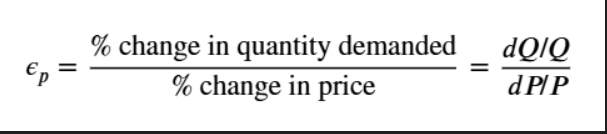

The coefficient ($\\gamma$) appears in specific demand models, often linear ones, that simplify this relationship for use in grid management equations. For example, a common model for change in power consumption 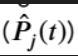 in response to price might be expressed as:

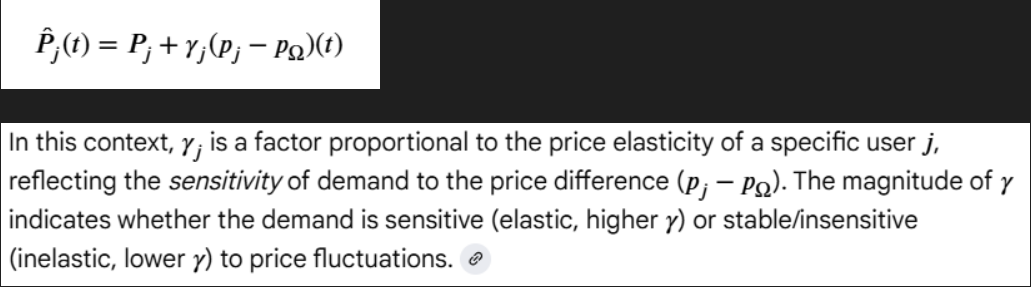

A higher coefficient $\gamma$ implies a more significant change in demand for a given change in price, which means higher price elasticity. This increased elasticity allows for more effective price-based demand-side management in electrical grids.

#### Distribution of Total Bill

In [ ]:
sns.histplot(data=df, x="g1", bins=50, kde=True,hue='stabf',label='stabf', element="step", fill=False, color="skyblue")

# Customize plot
plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

#### Unstable : Frequency increases as total bill amount rises.
- This suggests that in unstable grid conditions, higher total bills are more common.
- It reflects inefficiency or imbalance — instability drives costs upward.

#### Stable (orange): Frequency decreases as total bill amount rises.
- This means that in stable conditions, lower bills are more frequent.
- Stability keeps costs predictable and contained, preventing excessive billing.

- Stable grids → lower bills dominate, higher bills are rare.
- Unstable grids → higher bills dominate, showing economic inefficiency

The histogram compares billing distributions under stable vs unstable conditions. Stability keeps bills low and predictable, while instability shifts the distribution toward higher bills, signaling inefficiency and risk.


In [ ]:
dfStable = df[df['stabf'] == 'stable']
dfUnStable = df[df['stabf'] == 'unstable']
dfStable['stab'].mean(),dfUnStable['stab'].mean()

#### Kurtosis & Skewness analysis:


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
sns.histplot(data=dfStable, x="g1",ax=axes[0],kde = True)
axes[0].set_title(f"Hist Plot Stable")
axes[0].set_xlabel('g1')
axes[0].set_ylabel('g1' + ' Frequency')
skew_val = skew(dfStable['g1'])
kurt_val = kurtosis(dfStable['g1'], fisher=True)  # fisher=True gives excess kurtosis (normal = 0)
axes[0].text(x=dfStable['g1'].mean(), y=10,
         s=f"Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}",
         fontsize=12,color='red', bbox=dict(facecolor='white', alpha=0.6))

sns.histplot(data=dfUnStable, x="g1",ax=axes[1],kde=True)
axes[1].set_title(f"Hist Plot UnStable")
axes[1].set_xlabel('g1')
axes[1].set_ylabel('g1' + ' Frequency')
skew_val = skew(dfUnStable['g1'])
kurt_val = kurtosis(dfUnStable['g1'], fisher=True)  # fisher=True gives excess kurtosis (normal = 0)
axes[1].text(x=dfUnStable['g1'].mean(), y=10,
         s=f"Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}",
         fontsize=12,color='red', bbox=dict(facecolor='white', alpha=0.6))

Left Plot: Hist Plot Stable (Stable Grid):

This histogram shows the distribution of the price elasticity coefficient g1 when the electrical grid system is in a stable state. 

Distribution Shape: The distribution is heavily weighted towards lower values of g1. The frequency is highest around g1 approx 0.15 and decreases linearly as g1 increases.

Interpretation: A stable grid condition is most frequently associated with systems or scenarios where the price elasticity of demand is low (demand is inelastic).

Skewness: 0.32 (Slightly positive skew, indicating a tail extending slightly more to the right/higher g1 values, though visually it looks closer to uniform/negative skew from the peak)

Kurtosis: -1.03 (Platykurtic, meaning the distribution has lighter tails and is flatter than a normal distribution).

### Conclusions:

- Stable Grids tend to operate when demand is inelastic (low g1).
- Unstable Grids tend to occur when demand is elastic (high g1). 

### Pearson Correlation Hypothesis Test

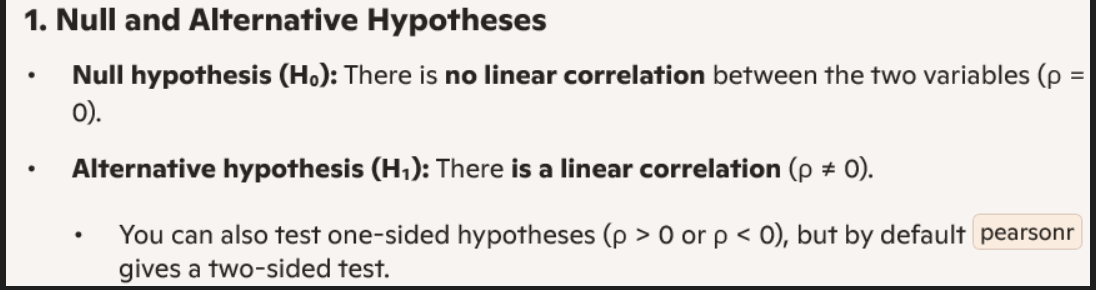

#### Correlation coefficient (r):
- Ranges from -1 to +1.
- Strength and direction of linear relationship.

#### P-value:
- Probability of observing such correlation if H₀ is true.
- If p < 0.05 (common threshold), reject H₀ → significant correlation.
- If p ≥ 0.05, fail to reject H₀ → no evidence of correlation.

In [ ]:
corr_coef, p_value = pearsonr(df['p1'], df['g1'])

print(f"Pearson correlation coefficient: {corr_coef:.3f}")
print(f"P-value: {p_value:.3f}")

if (p_value >= 0.05):
   print("fail to reject H₀ → no evidence of correlation p1 and g1.")
if (p_value < 0.05):
   print("reject H₀ → significant correlation.")


In [ ]:
df.plot(kind="scatter", x="g1", y="p1", grid=True, alpha=0.2)
plt.show()

In [ ]:
df.plot(kind="scatter", x="g1", y="p1", grid=True,
             label="p1",
             c="p1", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))

For any given level of price elasticity (e.g., at g1 = 0.2, 0.5, or 0.8), the observed power consumption p1 varies widely across the entire spectrum from low (blue) to high (red) values.

 based solely on this figure, the level of nominal power consumed in this system does not depend on, or correlate with, the value of the price elasticity coefficient g1.

#### Hist Plot coefficient (gamma) proportional to price elasticity

In [ ]:
# Create subplots: 3 rows, 1 column
fig, axes = plt.subplots(3, 1, figsize=(8, 12))


# Plot histograms for each feature
sns.histplot(data=df,x='g1', bins=100, kde=True, ax=axes[0], color="blue")
axes[0].set_title("coefficient g1 the value for electricity producer")

sns.histplot(data=df,x='g2', bins=100, kde=True, ax=axes[1], color="green")
axes[1].set_title("coefficient g2 the value for electricity consumer")

sns.histplot(data=df,x='g3', bins=100, kde=True, ax=axes[2], color="red")
axes[2].set_title("coefficient g3 the value for electricity consumer")
plt.show()

- g1 (producer coefficient): Distribution shows how generator contribution varies. Its regression coefficient tells us how strongly production affects stability.
- g2, g3 (consumer coefficients): Their distributions show consumption variability. Negative coefficients indicate that higher consumption destabilizes the grid.
- Together, the γ values quantify the balance (or imbalance) between production and consumption.

- The g coefficients (γ) are regression weights that measure how generator/consumer variables influence grid stability.
- Negative γ → destabilizing effect.
- Positive γ → stabilizing effect.
- Magnitude of γ → sensitivity (elasticity) of the system to that variable.


#### Investigate between nominal power produced(positive)(real) with coefficient (gamma) proportional to price elasticity

In [ ]:
sns.lmplot(data=df, x="p1", y="g1",line_kws={"color": "red"},hue='stabf',col='stabf')
plt.show()

**The scatter plots (stable vs unstable grid) had flat regression lines, meaning:**

- Weak or no correlation between p1 and g1.
- Nominal production (p1) doesn’t directly alter the elasticity coefficient (g1)

- Price elasticity measures responsiveness of demand/cost to changes in price.
    - Here, g1 acts as a proxy for elasticity:
    - If g1 is large in magnitude → system is highly sensitive (elastic).
    - If g1 is small → system is less sensitive (inelastic).
    - Since g1 is not strongly correlated with p1, it suggests that elasticity is driven more by consumption-side factors (p2, p3, p4) rather than nominal production alone


#### Investigate between nominal power produced(positive)(real) with coefficient (gamma) consumed proportional to price elasticity

In [ ]:
sns.lmplot(data=df, x="p1", y="g3",line_kws={"color": "red"},hue='stabf',col='stabf')

- Price elasticity of demand measures how consumption responds to price changes.
- Since g3 is proportional to elasticity:
- A higher g3 → consumers are more sensitive (elastic).
- A lower g3 → consumers are less sensitive (inelastic).
- The flat relationship with p1 means: production capacity doesn’t dictate consumer elasticity. Instead, elasticity is shaped by consumer-side dynamics (tariffs, demand response, or load behavior)


This scatter plot maps consumed power (p2) against consumer elasticity (g2), with marker size and color encoding the strength of g2.


In [ ]:
df.plot(kind="scatter", x="p2", y="g2", grid=True,
             s=df["g2"] / df['g2'].mean(), label="stabf",
             c="g2", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))

In [ ]:
dfStab = df[df['stabf'] == 'stable']
dfUnstab = df[df['stabf'] == 'unstable']

#### Hist Plot nominal power produced Grid stable/unstable

In [ ]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot histograms
sns.histplot(data=dfStab,x='p1', bins=100, kde=True, ax=axes[0], color="blue")
axes[0].set_title("Hist Plot nominal power produced Grid stable")

sns.histplot(data=dfUnstab,x='p1', bins=100, kde=True, ax=axes[1], color="green")
axes[1].set_title("Hist Plot nominal power produced Grid unstable")



In stable grid conditions, production is consistent and balanced, with most values near the average. This reflects predictable generator behavior.

In unstable grids, production levels are similar in average value, but the system experiences more frequent occurrences at those levels. This suggests overloading or repeated cycles of production that don’t translate into balanced consumption, contributing to instability.

histograms show that nominal power production (p1) is centered around the same mean in both stable and unstable grids. Stability comes from balanced, predictable production, while instability arises when production frequencies spike without matching consumption, stressing the grid.

In [ ]:
# additional code
dfUnstab['p1'].mean(),dfUnstab['p1'].sum(),dfUnstab['p1'].var(),dfUnstab['p1'].skew(),dfUnstab['p1'].kurt()

In [ ]:
# additional code
dfStab['p1'].mean(),dfStab['p1'].sum(),dfStab['p1'].var(),dfStab['p1'].skew(),dfStab['p1'].kurt()

### how the power consumed the electrical grid stability?

**Supply and demand equilibrium**: For the grid to be stable, the amount of electricity generated must perfectly match the amount being consumed at any given moment.

In [ ]:
# Check Supply and demand equilibrium when grid stable
var = f'{dfStab['p1'].sum():.3f}'
var2 = (dfStab['p2'].sum() + dfStab['p3'].sum() + dfStab['p4'].sum())
var2 = f'{abs(var2):.3f}'
print(f'Power Genrate when grid stable: {var}')
print(f'Power Consumed when grid stable: {var2}')
print(f'Check Supply and demand equilibrium exixt when grid stable: {var == var2}')

In [ ]:
# Check Supply and demand equilibrium when grid un-stable
var = f'{dfUnstab['p1'].sum():.3f}'
var2 = (dfUnstab['p2'].sum() + dfUnstab['p3'].sum() + dfUnstab['p4'].sum())
var2 = f'{abs(var2):.3f}'
print(f'Power Genrate when grid un-stable: {var}')
print(f'Power Consumed when grid un-stable: {var2}')
print(f'Check Supply and demand equilibrium exixt when grid un-stable: {var == var2}')

So we don't have enough evidance to check thisd anology; Supply and demand equilibrium: For the grid to be stable, the amount of electricity generated must perfectly match the amount being consumed at any given moment.

So you can see, mean of responce time {tau1/2/3/4} always Lower in case of grid Stable. 

- The output shows the mean and variance of tau1 for each stabf group.

In [ ]:
dfStable = df[df['stabf'] == 'stable']
dfUnStable = df[df['stabf'] == 'unstable']
result = df.groupby('stabf')['tau1'].agg(['mean', 'var'])
print(f'tau1 responce mean and variance \n{result}')
result = df.groupby('stabf')['tau2'].agg(['mean', 'var'])
print(f'tau2 responce mean and variance \n{result}')
result = df.groupby('stabf')['tau3'].agg(['mean', 'var'])
print(f'tau3 responce mean and variance \n{result}')
result = df.groupby('stabf')['tau4'].agg(['mean', 'var'])
print(f'tau4 responce mean and variance \n{result}')

In [ ]:
# Matrix Plot
g = sns.PairGrid(df)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)

### Lower triangular correlation heatmap


In [ ]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(15, 6))

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot heatmap with mask
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,ax=ax)

plt.title("Lower Triangular Correlation Heatmap")
plt.show()

Lower triangular correlation heatmap that displays the ***Pearson correlation coefficients*** between various parameters of an electrical grid system simulation. The color intensity and value within each cell indicate the strength and direction of the linear relationship between the two corresponding variables.

### Regressor Independent variable and Definitions:

($\tau{x}$) (tau1-tau4): Power generator response times.p[x] 
- (p1-p4): Nominal power consumed (negative) or produced (positive).
- g[x] (g1-g4): Coefficients ($\gamma{(x)}$) proportional to price elasticity.
- stab: The maximal real part of the characteristic equation root. (A positive value indicates linear instability). 

#### Analysis of Correlations:

#### 1. Stability (stab) Correlations:

**Strong Positive Correlation**: stab has a strong positive correlation with the generator response times: ($\tau{1}$) to ($\tau{4}$) (all around 0.28-0.29). This means that as the generator response times increase (slower response), the **value of stab increases**. Since a positive stab value indicates instability, slower generator response times increase the likelihood of system instability.

**Weak/Negligible Correlation**: stab has very weak correlation (around 0.01) with the nominal power consumed/produced (p1 to p4) and the price elasticity coefficients (g1 to g4).

2. **Correlations Between Generator Response Times ($\tau{x}$)** The tau variables ($\tau{1}$) to ($\tau{4}$) show negligible correlation with each other (values around 0.00 to 0.02). This suggests these **four response times are largely independent of one another in the dataset**.

3. **Correlations with Nominal Power (p):** The nominal power variable p1 shows a strong negative correlation with p2, p3, and p4 (all around -0.57 or -0.58). This indicates that the ***power consumed or produced by generator 1 is inversely related to that of the other generators***.

4. **Correlations with Price Elasticity Coefficients (g):** The g variables (g1 to g4) **show negligible correlation with most other parameters**, except for a weak positive correlation among themselves (around 0.28-0.31 between g2, g3, and g4).

The most significant our finding in this heatmap is that slower generator response times (($\tau{x}$) variables) are directly associated with increased electrical grid instability (stab). Other parameters (p and g variables) appear to have little direct linear relationship with the stability metric shown here.

Now we see relations between responce time & grid condtions.

### Responce Time:
Response time in grid stability refers to how quickly a power system component—like a generator, battery, or inverter—reacts to disturbances to help maintain frequency, voltage, and overall system balance.

Compute Response Time

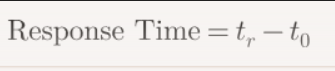

where t0 = start time of the disturbance.

tr = Identify the time, when the device begins to respond significantly (e.g., power output exceeds a threshold like 5% of rated capacity).

#### Plot Responce time and Grid Stability

Now  we are going to visualize the average value of a tau-x (responce time) and Grid stability conditions

Creates a bar plot using Seaborn that visualizes the mean and standard deviation of the tau1 variable for each category in stabf.

- Each bar represents the mean value of tau1 for a category in stabf.
- The height of the bar = mean of tau1
- The error bar = ±1 standard deviation
- Bars are colored by stabf, but since hue="stabf" matches x="stabf", each bar gets a unique color (but legend is hidden).

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(6, 15))
# Variables to plot
variables = ["tau1", "tau2", "tau3",'tau4']
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    sns.barplot(data=df, x='stabf', y = var,hue="stabf",errorbar='sd', legend=False,ax=axes[i])
    axes[i].set_title(f"Strip of {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Standard Error")

plt.tight_layout()

#### creates a bar plot using Seaborn and then adds labels to each bar using Matplotlib

- Each bar represents the total value of tau1 for a category in stabf.
- Labels on top of each bar show the exact sum.
- No error bars are shown.
- Useful for visualizing aggregated totals rather than averages.

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(6, 15))
# Variables to plot
variables = ["tau1", "tau2", "tau3",'tau4']
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    ax = sns.barplot(data=df, x='stabf', y = var,estimator="sum", legend=False,errorbar=None,ax=axes[i])
    ax.bar_label(ax.containers[0], fontsize=10);
    axes[i].set_title(f"Strip of {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel(f"Total Sum {var}")

plt.tight_layout()

This bar chart titled "Strip of tau1" compares the total sum of tau1 values between two categories: "unstable" and "stable". 

#### Chart Interpretation:

- X-axis (tau X(1/2/3/4)): Represents the two categories—unstable and stable.
- Y-axis (Total Sum tau1): Shows the cumulative sum of tau1 values for each category.
- Bar Heights:
- Unstable: ~36,590.8
- Stable: ~15,909.2

#### Final conclusions:

The unstable category has more than twice the total tau1 compared to the stable category. 
So we can conclude that higher tau1 values are associated with instability in the system.
We know that tau X represents a time of response, delay, or damping factor, this could imply:

- Systems with longer response times or slower dynamics tend to be unstable.
- Stability may require lower tau1 values, possibly indicating faster or more responsive behavior.

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(6, 15))
# Variables to plot
variables = ["tau1", "tau2", "tau3",'tau4']
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    ax = sns.barplot(data=df, x='stabf', y = var,estimator="mean", legend=False,errorbar=None,ax=axes[i])
    ax.bar_label(ax.containers[0], fontsize=10);
    axes[i].set_title(f"Strip of {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Grid Conditions")

plt.tight_layout()

####  visualize the distribution of the tauX variable across categories in stabf

A violin plot combines a box plot and a kernel density estimate (KDE):
- The width of the violin at each y-value shows the density of data points.
- The center line shows the **median**.
- The box inside shows the interquartile **range (IQR)**.
- The tails extend to the **min and max values** (or a clipped range).

In [ ]:
#sns.violinplot(data=df, x="stabf", y="tau1", hue="stabf", fill=True)

# Compute statistics
variables = ["tau1", "tau2", "tau3",'tau4']
q1 = []
q3 = []
irq = []
median  = []
min_val = []
max_val = []
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    q1.append(df[var].quantile(0.25))
    q3.append(df[var].quantile(0.75))
    irq.append((df[var].quantile(0.75) - df[var].quantile(0.25)))
    median.append(df[var].median())
    min_val.append(df[var].min())
    max_val.append(df[var].max())
# Display results
print(f"Q1 (25th percentile): {q1}")
print(f"Q3 (75th percentile): {q3}")
print(f"IQR (Q3 - Q1): {iqr}")
print(f"Median: {median}")
print(f"Min: {min_val}")
print(f"Max: {max_val}")
fig, axes = plt.subplots(4, 1, figsize=(6, 15))
# Variables to plot
variables = ["tau1", "tau2", "tau3",'tau4']
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    sns.violinplot(data=df, x='stabf', y = var,hue='stabf',ax=axes[i])
    axes[i].set_title(f"Viol of {var}")
    axes[i].set_xlabel('Grid Status')
    axes[i].set_ylabel(var)
    q1 = (df[var].quantile(0.25))
    q3 = (df[var].quantile(0.75))
    irq = ((df[var].quantile(0.75) - df[var].quantile(0.25)))
    median = (df[var].median())
    min_val = (df[var].min())
    max_val = (df[var].max())
    axes[i].text(x=-1, y=11,
         s=f"q1:{round(q1,2)},q3:{round(q3,2)},irq{round(irq,2)} median {round(median,3)}",
         fontsize=10,color='red', bbox=dict(facecolor='white', alpha=0.6))

plt.tight_layout()

Plot Type: A violin plot, which visualizes the distribution of numerical data (the y-axis) across different categories (the x-axis). The width of the shaded area represents the frequency or density of data points at that specific ($\tau{x}$) whered x = 1,2,3,4 value. 

The inner black bar and box indicate the interquartile range (IQR) and median.

### Analysis by Grid Status

**Unstable Grid Status (Left Violin, Blue):**

Distribution Shape: The distribution is wide and somewhat uniform across the entire range of ($\tau{x}$). It has a broad, almost heart-like shape. i.e. This suggests that a wide variety of response times for ($\tau{x}$) (from very fast near 0s to slower near 10s) frequently result in an **unstable grid system**. Instability is a common outcome across the full spectrum of observed ($\tau{x}$) values. The **median ($\tau{x}$)** value for unstable systems is around 5.3 seconds.

**Stable Grid Status (Right Violin, Orange):**

This distribution is **narrower and taller**, with distinct peaks around the median (approximately 3.5 to 4 seconds). It has a **more "pinched" or "hourglass" shape** compared to the unstable distribution. A stable grid status is associated with a more constrained range of ($\tau{x}$) values. Stability seems to be most likely when ($\tau{x}$) falls within a specific, narrower band of response times. Stable outcomes are less common than unstable ones (judging by the overall density comparison with a potentially larger dataset not fully visible here), and require specific, faster generator response times. 

Finally instability can happen with almost any generator response time ($\tau{x}$), stability is a more selective condition that predominantly occurs within a specific, narrower range of ($\tau{x}$) values (roughly between 2s and 7s), with a median lower than that of the unstable condition. 


#### Hist Plot of tau1 with Skew and Kurtosi - Analysis

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(6, 15))
# Variables to plot
variables = ["tau1", "tau2", "tau3",'tau4']
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    sns.histplot(data=df, x=var,bins=50, kde=False,ax=axes[i])
    # Calculate skewness and kurtosis
    skew_val = skew(df[var])
    kurt_val = kurtosis(df[var])  # Default is Fisher's definition (excess kurtosis)
    axes[i].set_title(f"Hist Plot of {var} with Skew and Kurtosis")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel(var + ' Frequency')
    axes[i].text(x=df[var].mean(), y=10,
         s=f"Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}",
         fontsize=12,color='red', bbox=dict(facecolor='white', alpha=0.6))
plt.tight_layout()

#### Hist Plot of tau1 with Skew and Kurtosi - Analysis

"Hist Plot of tau1 with Skew and Kurtosis" provides a visual and statistical summary of the distribution of the variable tau1.

#### Visual Interpretation:

- X-axis (tau1): Represents the range of values for the variable tau1, spanning from 0 to 10.
- Y-axis (tau1 Frequency): Indicates how many observations fall into each bin.
- Bars: The histogram shows a relatively uniform distribution—bars are nearly equal in height across the range, suggesting that tau1 values are evenly spread.

#### Statistical Annotations
- ***Skewness: −0.00:***
- This value is essentially zero, indicating a **perfectly symmetric distribution**.
- There's no noticeable lean to the left or right—tau1 is balanced around its center.
- ***Kurtosis: −1.20:***
- This is excess kurtosis, meaning it's measured relative to a **normal distribution** (which has kurtosis = 0).
- A negative value like −1.20 suggests a **platykurtic distribution**:
- Flatter peak
- Thinner tails
- Less extreme values than a normal distribution

#### Finals concusions:

- tau1 is uniformly distributed, both visually and statistically.
- It likely comes from a controlled or synthetic process where values are intentionally spread evenly.
- This kind of distribution is ideal for testing algorithms or modeling systems that require non-biased input.
- From a modeling perspective:
- You won’t need to transform tau1 for symmetry.
- It may not contribute much to predictive power unless it interacts with other variables.


#### Correlation matrix between responce time ($\tau{x}$)

In [ ]:
# Compute correlation matrix
dfTauParam = df.loc[:,['tau1','tau2','tau3','tau4']]
corr = dfTauParam.corr(numeric_only=True)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", center=0, fmt=".2f")

plt.title("Lower Triangular Correlation Matrix Heatmap")
plt.show()

#### Structure of the Heatmap

- Axes: Both x and y axes list the variables (tau1, tau2, tau3, tau4).
- Lower triangle only: The upper triangle is masked to avoid redundancy since correlation matrices are symmetric.

#### About Colors:
- Red shades → positive correlation
- Blue shades → negative correlation
- White/light → near zero correlation
- Annotations: Each cell contains the exact correlation coefficient

#### Correlation Values
- tau2 vs tau1: 0.02 → very weak positive correlation
- tau3 vs tau1: −0.01 → very weak negative correlation
- tau3 vs tau2: 0.01 → very weak positive correlation
- tau4 vs tau1: −0.02 → very weak negative correlation
- tau4 vs tau2: −0.00 → essentially no correlation
- tau4 vs tau3: 0.00 → no correlation

#### Result analysis
- All correlations are close to zero, meaning there is ***no strong linear relationship*** among tau1, tau2, tau3, and tau4.
- The **variables appear to be independent of each other** in terms of linear association.

- Each tau variable may represent distinct aspects of the system.
- **Multicollinearity is not a concern here** (good for regression modeling).
- If these are time constants or parameters, they are likely sampled independently.

The system seems designed or sampled to avoid overlap between these parameters. Response time are not correlate with each other. So they are linearly Independent and play very significant role in models.

- **Feature selectio**n: Since correlations are negligible, we can safely include all tau variables in a model without redundancy.

## Scatter plots, comparing the relationship between ($\tau{1}$) (x-axis) and t($\tau{x}$) (y-axis) under two different stability conditions

In [ ]:
markers = {"stable": "s", "unstable": "X"}
#fig, axes = plt.subplots(3, 1, figsize=(6, 15))
# Variables to plot
var1 = 'tau1'
var2 = ["tau2", "tau3",'tau4']
# Loop through variables and plot each histogram
for i, var in enumerate(var2):    
    gx = sns.relplot(
    data=df, x=var1, y=var2[i],
    col="stabf",size = var2[i],
    kind="scatter",alpha = 0.5,markers=markers     
    )
    # Calculate skewness and kurtosis
    mean_var1 = df[var1].mean()
    variance_var1 = df[var1].var()  # Default is Fisher's definition (excess kurtosis)
    mean_var2 = df[var2[i]].mean()
    variance_var2 = df[var2[i]].var()
    # Set the overall title for the figure
    gx.fig.suptitle(f'Relationship Between {var1} vs {var2[i]}', fontsize=12)
    gx.fig.tight_layout()
    gx.fig.subplots_adjust(top=0.9)  # move title down a bit

    # Adjust the subplot parameters for a tight layout, making room for the title
    #g.fig.subplots_adjust(top=0.9) # Adjust the 'top' margin to prevent title overlap


    #axes[i].set_title(f"Scatter Plot of {var1} vs {var2[i]}")
    #axes[i].set_xlabel(var1)
    #axes[i].set_ylabel(var2[i])    
plt.tight_layout()

#### Scatter Plot analysis

This scatter plot illustrates the relationship between two time constants ($\tau{1}$) and ($\tau{x}$) wher x =2,3,4 and the resulting stability of an electrical grid system. 

The data points are split into two panels: one showing combinations of ($\tau{1}$) and ($\tau{x}$) that lead to an **unstable stat**e, and the other showing combinations that result in a **stable state**.

As specified, ($\tau{1}$) and ($\tau{x}$) represent the response times of power generators within the system. These time constants relate to how quickly different parts of the system react to disturbances.

**Unstable Region (Left Panel):** The left plot, labeled "stabf = unstable", shows that instability occurs across a wide range of values for both ($\tau{1}$) and ($\tau{x}$). The data points are densely distributed, suggesting that instability is the more common outcome when these parameters are randomly varied within the tested ranges (approximately 1 to 10 seconds).

**Stable Region (Right Panel):** The right plot, labeled "stabf = stable", shows the specific combinations of \($\tau{1}$) and ($\tau{x}$) where the system remains stable. Notably, the data points in this panel are much less dense than in the unstable panel, indicating that a stable condition is less frequent and likely constrained to a smaller, specific "stability domain" within the parameter space.

In the **unstable case**, there appears to be **no clear pattern or correlation** between ($\tau{1}$) and ($\tau{x}$); most combinations result in instability.

In the **stable case**, there appears to be a **slight negative correlation** as ($\tau{1}$) increases, higher values of ($\tau{x}$) become less common.

So we can conclude The plot highlights the challenge of maintaining power system stability. The system's ability to return to a balanced state after a ***disturbance is highly dependent on specific combinations of generator response times***, with many configurations leading to instability.

In both the stable and unstable conditions, there is a nearly perfect positive linear relationship between p1 and pAdd. The data points form a tight, straight line that goes from the bottom left to the top right of both graphs. So we can varify that 

p1 = p2+p3+p4

#### Trying to investigate co-related variable

In [ ]:
# Create histogram

dfStab = df[df['stabf'] == 'stable']
ax = sns.histplot(data=dfStab, x="stab", bins=30, color="skyblue", edgecolor="black",                  
                  kde=True)
sns.kdeplot(data=dfStab, x="stab", color="red", lw=2, linestyle="--", ax=ax)

# Set title and labels
ax.set_title("dominant eigenvalue", fontsize=14, weight="bold")
ax.set_xlabel("stab[dominant eigenvalue]", fontsize=12)
ax.set_ylabel("stab Frequency", fontsize=12)
skew_val = dfStab['stab'].skew()
kurt_val = dfStab['stab'].kurt()
ax.text(x=-0.08, y=50,
         s=f"Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}",
         fontsize=12,color='red', bbox=dict(facecolor='white', alpha=0.6))
plt.show()


In [ ]:
dfStab = df[df['stabf'] == 'unstable']
ax = sns.histplot(data=dfStab, x="stab", bins=30, color="skyblue", edgecolor="black",                  
                  kde=True)
sns.kdeplot(data=dfStab, x="stab", color="red", lw=2, linestyle="--", ax=ax)

# Set title and labels
ax.set_title("dominant eigenvalue", fontsize=14, weight="bold")
ax.set_xlabel("stab[dominant eigenvalue]", fontsize=12)
ax.set_ylabel("stab Frequency", fontsize=12)
skew_val = dfStab['stab'].skew()
kurt_val = dfStab['stab'].kurt()
ax.text(x=0.10, y=50,
         s=f"Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}",
         fontsize=12,color='red', bbox=dict(facecolor='white', alpha=0.6))
plt.show()

The dominant eigenvalue (stab) is the primary metric for system stability in power systems engineering. In this context:
- Positive stab values (as seen in this figure) indicate that the system is unstable.
- Negative stab values would indicate a stable system.

The distributions show that stable operations are centered around a specific negative eigenvalue, and unstable operations are centered around a specific positive eigenvalue. The visual separation implies that the system is highly sensitive to the parameters that push the dominant eigenvalue across the zero boundary.

**Left Plot (Stable):**
- Skewness: -0.30 (Slight negative skew; the tail extends slightly further into "more stable" negative values).
- Kurtosis: -0.66 (Platykurtic; slightly flatter than a standard normal distribution).

**Right Plot (Unstable):**
- Skewness: 0.36 (Slight positive skew; the tail extends slightly further into "more unstable" positive values).
- Kurtosis: -0.63 (Platykurtic; also slightly flatter than a standard normal distribution).

### Empirical Cumulative Distribution Function (ECDF)

Compares the distributions of the dominant eigenvalue (stab) for stable versus unstable scenarios in the electrical grid system.

In [ ]:
sns.histplot(
    data=df, x="stab", hue="stabf",
    hue_order=["stable", "unstable"],
    log_scale=False, element="step", fill=False,
    cumulative=True, stat="density", common_norm=False,
)

1. Stable Distribution (Blue Line):

- The blue line reaches a cumulative density of 1.0 exactly when stab reaches 0.000.
- This indicates that 100% of the data points classified as "stable" have a dominant eigenvalue less than or equal to 0.000.
- The steepest part of the curve occurs between stab values of -0.04 and 0.00, meaning most stable operations fall within this narrow range

2. Unstable Distribution (Orange Line):

- The orange line does not begin rising until stab reaches 0.000.
- It reaches a cumulative density of 1.0 near stab = 0.100.
- This indicates that 100% of the data points classified as "unstable" have a dominant eigenvalue greater than 0.000.

The figure visually confirms the definition of stability used in the dataset: any system configuration resulting in a dominant eigenvalue of zero or less is labeled stable, and any configuration resulting in an eigenvalue greater than zero is labeled unstable. The plot demonstrates a clean separation between the two distributions with no overlap across the stability boundary.

#### How dominant eigenvalue determining the stability of an electrical grid ?

The dominant eigenvalue of a power system’s state matrix determines grid stability because its real part indicates whether system oscillations decay or grow.

- If the **dominant eigenvalue has a negative real part**, **disturbances die out and the grid is stable**; 
- if **positive**, **oscillations amplify** and the grid becomes **unstable**.

In [ ]:
dfStab = df[df['stabf'] == 'stable']
dfUnStab = df[df['stabf'] == 'unstable']
print(f'when grid stable, total dominant eigenvalue > 0 = {dfStab[dfStab['stab']>0].shape[0]}')
print(f'when grid stable, total dominant eigenvalue < 0 = {dfStab[dfStab['stab']<0].shape[0]}')
print(f'Mean value when grid stable: {dfStab['stab'].mean()}')

print(f'when grid un-stable, total dominant eigenvalue > 0 = {dfUnStab[dfUnStab['stab']>0].shape[0]}')
print(f'when grid un-stable, total dominant eigenvalue < 0 = {dfUnStab[dfUnStab['stab']<0].shape[0]}')
print(f'Mean value when grid un-stable: {dfUnStab['stab'].mean()}')

We can see Grid stable when  dominant eigenvalue <0.


### Role of Eigenvalues in Grid Stability

**System Representation**: 
- Electrical grids are modeled using differential equations that describe generator dynamics, inverter controls, and network interactions. These equations can be linearized into a state-space model.

**Eigenvalues of State Matrix:**
 - The eigenvalues of this matrix represent the **system’s natural modes of oscillation** (frequency and damping).

**Dominant Eigenvalue:**
- The eigenvalue with the largest real part (closest to zero or positive) is called the dominant eigenvalue.
- It dictates the slowest-decaying or fastest-growing mode, making it the most critical for stability assessment.

#### Example
Suppose a grid’s linearized state matrix yields eigenvalues:

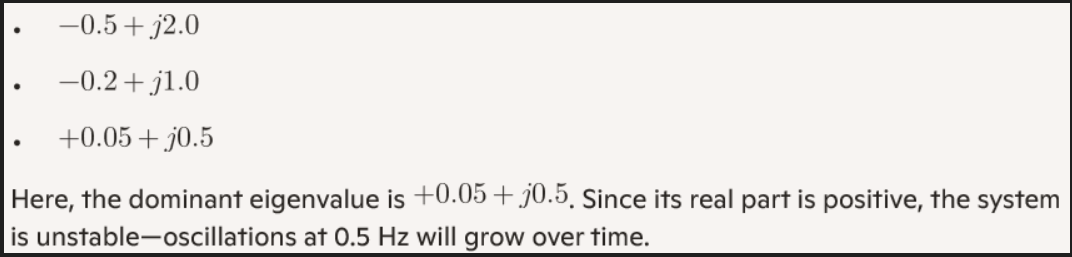

The dominant eigenvalue acts like the “health indicator” of the grid’s dynamic response. 

Negative → safe and stable; 

positive → unstable and risky.

Why It Matters

Understanding the dominant eigenvalue is crucial for:
- Designing robust inverter controllers in renewable-heavy grids.
- Preventing blackouts by ensuring oscillations are damped.
- Guiding grid reinforcement strategies (e.g., adding stabilizers or adjusting operating points).


### Examin correlations between responce time and dominant eigenvalue

In [ ]:
corr = df.loc[:,["tau1","tau2","tau3","tau4",'stab']].corr(numeric_only=True)
mask = np.tril(np.ones_like(corr, dtype=bool))
lower_corr = corr.where(mask)
# Plot heatmap with mask
#plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=~mask, annot=True, cmap='coolwarm', center=0)
plt.title("Upper Triangular Correlation Heatmap")
plt.show()

### SciPy’s Pearson correlation test:

### **Hypothesis Test :**

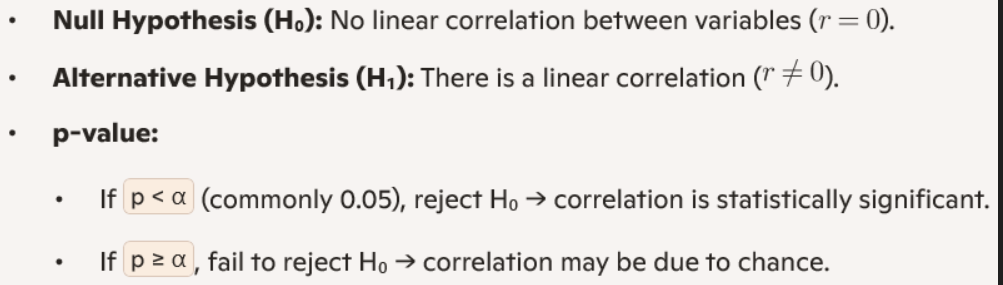

In [ ]:
import itertools
alpha = 0.05
for (name1, arr1), (name2, arr2) in itertools.combinations(df.loc[:,["tau1","tau2","tau3","tau4",'stab']].items(), 2):
    corr_coff, p_value = pearsonr(arr1, arr2)
    print(f"correlations b/w {name1} vs {name2}: corr coff={corr_coff:.3f}, p_val={p_value:.3g}")
    if p_value < alpha:
        print(f"reject H₀ → correlation is statistically significant between {name1} & {name2}")
    if p_value >= alpha:
        print(f"fail to reject H₀ → correlation may be due to chance between {name1} & {name2}")

### Explaine Heatmap figure
1. Correlation between Response Functions (tau values)
- tau1 vs. tau2: +0.016 (Very weak positive correlation)
- tau1 vs. tau3: -0.006 (Negligible correlation)
- tau1 vs. tau4: -0.017 (Negligible correlation)

& we get same result from Null hypothesis test

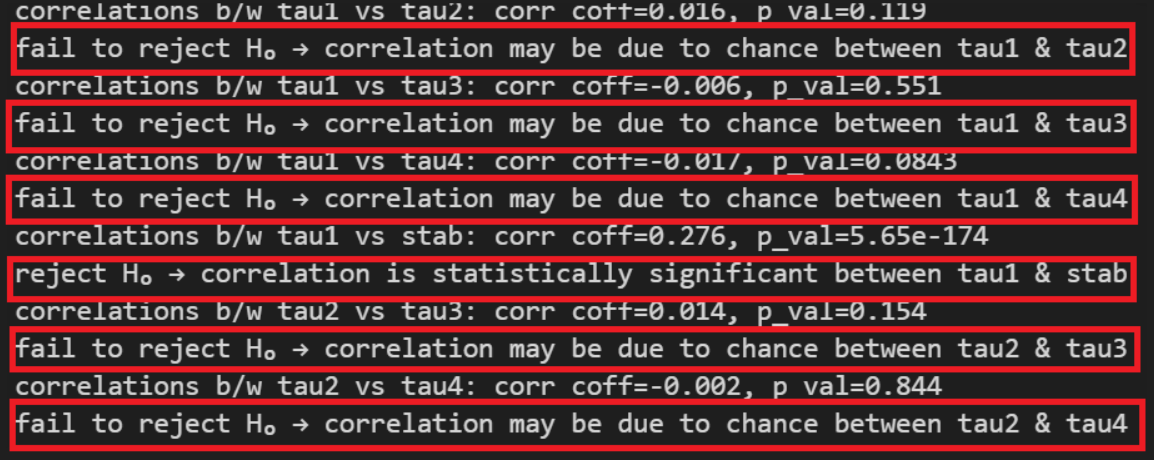

2. Correlation between Response Functions and Stability (stab)
- stab vs. tau1: +0.28 (Weak positive correlation)
- stab vs. tau2: +0.29 (Weak positive correlation)
- stab vs. tau3: +0.28 (Weak positive correlation)
- stab vs. tau4: +0.28 (Weak positive correlation)

The weak positive correlation suggests that as any single component's response time increases (higher ($\tau_{x}$)), the system's dominant eigenvalue tends to increase slightly, moving it incrementally toward a less stable state. However, because the correlations are only 0.28-0.29, no single response function is a strong predictor of stability on its own. The stability outcome depends on the combined effect and interactions of all variables.



### Examin lmplot between $\tau_{1}$ & stab categorized by the stability label stabf

In [ ]:
sns.lmplot(x="tau1", y="stab", data=df,col="stabf",
           scatter_kws={"color": "red","alpha":0.09, "s":50},
           line_kws={"color":"blue"}
)
plt.show()

- Left Plot (stabf = unstable): All data points have a positive stab value (above 0.0), ranging from approximately 0.0 to over 0.1.
- Right Plot (stabf = stable): All data points have a negative stab value (below 0.0), ranging from approximately -0.08 to 0.0.

**Slight Positive Correlation**: In both the stable and unstable datasets, the red line has a very slight positive slope. This indicates a weak positive correlation between $\tau_{1}$ and stab.

As the generator's response time constant ***$\tau_{1}$*** increases, the dominant eigenvalue (stab) tends to slightly increase (become less negative or more positive). This suggests that slower generator response times contribute marginally to reduced system stability.


## Examin correlation between coefficient (gamma) price elasticity & stab

In [ ]:
corr = df.loc[:,["g1","g2","g3","g4",'stab']].corr(numeric_only=True)
mask = np.tril(np.ones_like(corr, dtype=bool))
lower_corr = corr.where(mask)
# Plot heatmap with mask
#plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=~mask, annot=True, cmap='coolwarm', center=0)
plt.title("Upper Triangular Correlation Heatmap")
plt.show()

In [ ]:
for (name1, arr1), (name2, arr2) in itertools.combinations(df.loc[:,["g1","g2","g3","g4",'stab']].items(), 2):
    corr_coff, p_value = pearsonr(arr1, arr2)
    print(f"correlations b/w {name1} vs {name2}: corr coff={corr_coff:.3f}, p_val={p_value:.3g}")
    if p_value < alpha:
        print(f"reject H₀ → correlation is statistically significant between {name1} & {name2}")
    if p_value >= alpha:
        print(f"fail to reject H₀ → correlation may be due to chance between {name1} & {name2}")

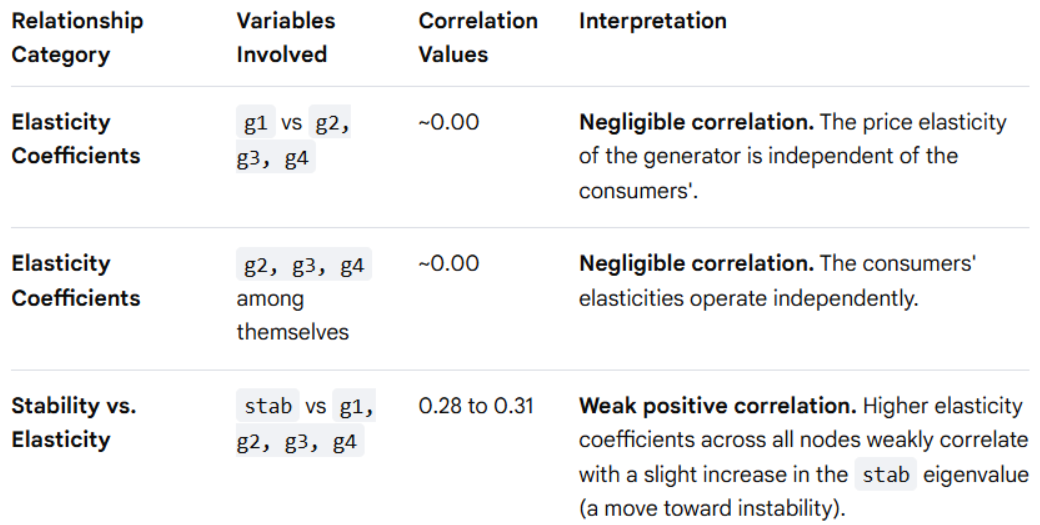

Same cthing we can found in null hypothesis test. we are faile to fail to reject H₀ b/w g1,g2,g3,g4. Whre a verry week correlation exixt bwtween another params.


In [ ]:
sns.lmplot(x="g1", y="stab", data=df,col="stabf",
           scatter_kws={"alpha":0.09, "s":50},
           line_kws={"color":"red"}
)
plt.show()

In [ ]:
sns.lmplot(x="g1", y="stab", data=df,col="stabf",
           scatter_kws={"color": "blue","alpha":0.09, "s":50},
           line_kws={"color":"red"}
)
plt.show()

In [ ]:
g = sns.FacetGrid(df, col="stabf")
g.map_dataframe(sns.scatterplot, x="g1", y="stab",color="red", alpha=0.07, s=60
)


In [ ]:
# Compute covariance matrix
cov = df.cov(numeric_only=True).round(decimals=3)
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(cov, dtype=bool))
# Plot heatmap with mask
plt.figure(figsize=(15,10))
sns.heatmap(
    cov,
    mask=mask,          # hide upper triangle
    annot=True,         # show covariance values
    cmap="coolwarm",    # color palette
    center=0,           # center colormap at zero
    square=True,        # square cells
    linewidths=0.5
)
plt.title("Lower Triangular Covariance Heatmap")
plt.show()

#### Get outlier in Dataset

In [ ]:
# Calculate IQR
numeric_cols = df.select_dtypes(include='number').columns

# Function to detect outliers
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

# Apply to each numeric column
outlier_summary = {}
for col in numeric_cols:
    outliers = detect_outliers_iqr(df[col])
    outlier_summary[col] = {
        'count': len(outliers),
        'indices': outliers.index.tolist()
    }

# Display summary
for col, info in outlier_summary.items():
    print(f"{col}: {info['count']} outliers → indices: {info['indices']}")

In [ ]:
# Encode target variable (stable=1, unstable=0)
df['stabf'] = df['stabf'].map({'stable': 1, 'unstable': 0})
# Separate predictors and target
X = df.drop(columns=['stabf'])
y = df['stabf']
# Convert back to DataFrame for readability
X = pd.DataFrame(X, columns=X.columns)
print(X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Step 6: Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 14.2 Multicollinearity detections technique:

##### 14.2.1. Variance Inflation Factor (VIF):

**Definition:**  

Variance Inflation Factor (VIF) is a statistical measure used to detect the presence and severity of **multicollinearity** in regression analysis. It quantifies how much the variance of a regression coefficient is inflated due to linear dependence among predictor variables.

#### Calculations Variance Inflation Factor (VIF):

For predictor $X_j$, the VIF is defined as:

$C_{jj}=\frac{1}{1-R_j^2}$

$C_{jj}$ → diagonal element of the covariance matrix $(X'X)^{-1}$. $R_j^2$ → the coefficient of determination when regressing predictor $X_j$ on all other predictors.

So:

$VIF_j=C_{jj}=\frac{1}{1-R_j^2}$

where $R_j^2$ is the coefficient of determination when regressing $X_j$ on all the other predictors.

If $R_j^2$ is close to 1, it means predictor $X_j$ is highly explained by other predictors → strong multicollinearity. As $R_j^2\rightarrow 1$, the denominator $(1-R_j^2)$ becomes very small → $VIF_j$ becomes very large. A **large VIF indicates that the variance of the coefficient estimate for $X_j$ is inflated due to correlation with other predictors.**

VIF measures how much the variance of the estimated coefficient $\hat \beta_j$ is inflated due to multicollinearity


#### how multicollinearity is diagnosed and deal with using VIF (Variance Inflation Factor) ?

##### 14.2.1.1 Calculate  square root of the j‑th VIF

Qus: why we calculate square root of the j‑th VIF ?

Ans: The square root of the jth VIF indicates **how much longer the confidence interval** for the jth regression coefficient is because of multicollinearity. - The square root of the j‑th VIF gives the inflation factor of the standard error of $\hat {\beta }_j$.

$\sqrt{VIF_j}=\frac{\mathrm{SE\  with\  multicollinearity}}{\mathrm{SE\  without\  multicollinearity}}$

Please see another approch to understand the square root of the j‑th VIF

$\sqrt{VIF_j}=\sqrt{C_{jj}}=\frac{L_j}{L^*}$

Where:
- $VIF_j$ = Variance Inflation Factor for predictor $X_j$.
- $C_{jj}$ = diagonal element of the covariance matrix for coefficient $j$.
- $L_j$ = length of the confidence interval for coefficient $j$.
- $L^*$ = length of the confidence interval if predictors were orthogonal (uncorrelated)

##### 14.2.1.2 length of Confidence Interval:

The confidence interval length for coefficient $j$ is:

$L_j=2\cdot \sqrt{C_{jj}\cdot \sigma ^2}\cdot t_{\alpha /2,n-p-1}$

In an orthogonal design (no multicollinearity), the interval length is:

$L^*=2\cdot \sigma \cdot t_{\alpha /2,n-p-1}$
- Therefore:
$\sqrt{VIF_j}=\frac{L_j}{L^*}$

$\sqrt{VIF_j}$ tells how much **longer the confidence interval for coefficient** $j$ is compared to the ideal case with no multicollinearity.

Take Example:
If $\sqrt{VIF_j}=2$, the confidence interval for $\beta _j$ is $twice$ as wide as it would be in an orthogonal design.

If $\sqrt{VIF_j}=5$, the interval is five times wider.

This directly links multicollinearity to loss of precision in estimating coefficients

#### 14.2.1.3 Final conclusions:

Large $\sqrt{VIF_j}$ means your **coefficient estimates are unstable and less reliable**. Even if the predictor is theoretically important, high multicollinearity makes it hard to distinguish its unique effect. This is why **thresholds like VIF > 10 (or equivalently $\sqrt{VIF}>3.16$)** are **often used to flag problematic predictors**

- Interpretation:
    - VIF = 1–5 → Low correlation, safe.
    - VIF = 5–10 → Moderate correlation, caution.
    - VIF > 10 → High multicollinearity, problematic.

- Square root of VIF → tells you how much wider the confidence interval for $\hat \beta _j$ is compared to an orthogonal design (no correlation).

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Dropping power generator and receiver. This will cause error in code due to
# divide by zero.
vifX = X.drop(['p1','p2','p3','p4'],axis=1) 
# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = vifX.columns
vif_data["VIF"] = [variance_inflation_factor(vifX.values, i) for i in range(vifX.shape[1])]
print(vif_data)

#### Result Analysis

- VIF = 1 → No correlation with other predictors.
- VIF between 1–5 → Moderate correlation, usually acceptable.
- VIF > 5 (sometimes >10) → Strong multicollinearity, problematic for regression stability.

See Result

- Features like tau1–tau4 and g1–g4 have VIF ≈ 4 → moderate correlation, not extreme but worth monitoring.
- stab has VIF ≈ 1.37 → almost no multicollinearity.
- This suggests tau/g features are somewhat interrelated, but not dangerously so.



In [ ]:
# Train Logistic Regression model
LogRegs_l2_liblinear = LogisticRegression(
                              C = 1.0, # Default
                              penalty='l2',
                              #l1_ratio=1, # Use with only elatice net
                              tol=0.0001, # Default
                              fit_intercept=True, # Const added in Models
                              solver='liblinear', # Default
                              max_iter=1000, # Default = 100
                              verbose=0 # Default 0
                              )
LogRegs_l2_liblinear.fit(X, y)
# Get Models Params
coef_series = pd.Series(
    [LogRegs_l2_liblinear.intercept_[0]] + list(LogRegs_l2_liblinear.coef_[0]),
    index=['Intercept'] + list(X.columns),
    name='Coefficient'
)

#### odds ratios
- Coefficients (β) are in log-odds, which are hard to interpret directly.
- Odds ratios (exp(β)) are intuitive: they show multiplicative changes in odds.
    - if OR > 1 : odds of outcome increse as xj increse (positive association)
    - if OR < 1 : odds of outcome reduces as xj increse (negative association)
    - if OR = 1 : No effect

In [ ]:
# Log odds cofficient
coef = coef_series
# Get -ve log odds
coef_n = coef[coef < 0]
# OR of -ve Log odds
conf_exp = np.exp(coef_n)
dfOr = pd.DataFrame({'LogOdds':coef_n,'OR':np.round(conf_exp,3)},index = coef_n.index)
tableDispFormatt('OR for -Ve Log Odds negative association')
print(dfOr)
coef_p = coef[coef > 0]
# OR of +ve Log odds
conf_exp = np.exp(coef_p)
dfOrPov = pd.DataFrame({'LogOdds':coef_p,'OR':np.round(conf_exp,3)},index = coef_p.index)
tableDispFormatt('OR for +Ve Log Odds positive association')
print(dfOrPov)